# Pretrained CNN Models — Layer & Parameter Analysis

Pretrained model တွေရဲ့ **internal architecture** ကို analysis လုပ်ကြည့်မှာဖြစ်ပါတယ်။
Training/Validation မဟုတ်ပဲ **layer structure** နဲ့ **parameter counts** ကိုသာ စစ်ကြည့်ပါမယ်။

**Models covered:**

| Model | Key Innovation |
|-------|---------------|
| ResNet-18 / 50 / 152 | Skip Connections (Residual Learning) |
| EfficientNet-B0 / B7 | Compound Scaling (width × depth × resolution) |
| MobileNetV2 / V3 | Depthwise Separable Convolutions, Inverted Residuals |
| ConvNeXt-Tiny / Base | Modernized ConvNet (inspired by Vision Transformers) |
| InceptionResNetV2 (FaceNet backbone) | Inception modules + Residual connections |

In [2]:
# --- All Model Versions & Differences ---
import torchvision.models as models

weight_classes = {
    # ResNet Family
    'ResNet-18':  models.ResNet18_Weights,
    'ResNet-34':  models.ResNet34_Weights,
    'ResNet-50':  models.ResNet50_Weights,
    'ResNet-101': models.ResNet101_Weights,
    'ResNet-152': models.ResNet152_Weights,
    # EfficientNet Family
    'EfficientNet-B0': models.EfficientNet_B0_Weights,
    'EfficientNet-B1': models.EfficientNet_B1_Weights,
    'EfficientNet-B2': models.EfficientNet_B2_Weights,
    'EfficientNet-B3': models.EfficientNet_B3_Weights,
    'EfficientNet-B4': models.EfficientNet_B4_Weights,
    'EfficientNet-B5': models.EfficientNet_B5_Weights,
    'EfficientNet-B6': models.EfficientNet_B6_Weights,
    'EfficientNet-B7': models.EfficientNet_B7_Weights,
    # MobileNet Family
    'MobileNetV2':      models.MobileNet_V2_Weights,
    'MobileNetV3-Small': models.MobileNet_V3_Small_Weights,
    'MobileNetV3-Large': models.MobileNet_V3_Large_Weights,
    # ConvNeXt Family
    'ConvNeXt-Tiny':  models.ConvNeXt_Tiny_Weights,
    'ConvNeXt-Small': models.ConvNeXt_Small_Weights,
    'ConvNeXt-Base':  models.ConvNeXt_Base_Weights,
    'ConvNeXt-Large': models.ConvNeXt_Large_Weights,
}

rows = []
for model_name, weight_cls in weight_classes.items():
    for w in weight_cls:
        meta = w.meta
        acc1 = meta.get('_metrics', {}).get('ImageNet-1K', {}).get('acc@1', '-')
        acc5 = meta.get('_metrics', {}).get('ImageNet-1K', {}).get('acc@5', '-')
        recipe = meta.get('recipe', '-')
        # input size
        crop = w.transforms().crop_size[0] if hasattr(w.transforms(), 'crop_size') else '-'
        is_default = (w == weight_cls.DEFAULT)
        rows.append({
            'Model': model_name,
            'Weight Version': w.name,
            'DEFAULT': '✅' if is_default else '',
            'Top-1 Acc': f"{acc1}%" if isinstance(acc1, (int, float)) else acc1,
            'Top-5 Acc': f"{acc5}%" if isinstance(acc5, (int, float)) else acc5,
            'Input Size': crop,
        })

import pandas as pd
df_versions = pd.DataFrame(rows)

# --- Display by family ---
families = {
    'ResNet':       [n for n in weight_classes if 'ResNet' in n],
    'EfficientNet': [n for n in weight_classes if 'Efficient' in n],
    'MobileNet':    [n for n in weight_classes if 'Mobile' in n],
    'ConvNeXt':     [n for n in weight_classes if 'ConvNeXt' in n],
}

for family, model_names in families.items():
    print(f"\n{'='*80}")
    print(f"  {family} Family — Available Pretrained Weights")
    print(f"{'='*80}")
    subset = df_versions[df_versions['Model'].isin(model_names)]
    display(subset.reset_index(drop=True))

print("\n💡 DEFAULT = PyTorch team ရဲ့ recommended best weights (latest recipe)")
print("   V2 versions → better training recipe (longer training, augmentation, etc.) but same architecture")


  ResNet Family — Available Pretrained Weights


,Model,Weight Version,DEFAULT,Top-1 Acc,Top-5 Acc,Input Size
0,ResNet-18,IMAGENET1K_V1,✅,69.758%,89.078%,224
1,ResNet-34,IMAGENET1K_V1,✅,73.314%,91.42%,224
2,ResNet-50,IMAGENET1K_V1,,76.13%,92.862%,224
3,ResNet-50,IMAGENET1K_V2,✅,80.858%,95.434%,224
4,ResNet-101,IMAGENET1K_V1,,77.374%,93.546%,224
5,ResNet-101,IMAGENET1K_V2,✅,81.886%,95.78%,224
6,ResNet-152,IMAGENET1K_V1,,78.312%,94.046%,224
7,ResNet-152,IMAGENET1K_V2,✅,82.284%,96.002%,224



  EfficientNet Family — Available Pretrained Weights


,Model,Weight Version,DEFAULT,Top-1 Acc,Top-5 Acc,Input Size
0,EfficientNet-B0,IMAGENET1K_V1,✅,77.692%,93.532%,224
1,EfficientNet-B1,IMAGENET1K_V1,,78.642%,94.186%,240
2,EfficientNet-B1,IMAGENET1K_V2,✅,79.838%,94.934%,240
3,EfficientNet-B2,IMAGENET1K_V1,✅,80.608%,95.31%,288
4,EfficientNet-B3,IMAGENET1K_V1,✅,82.008%,96.054%,300
5,EfficientNet-B4,IMAGENET1K_V1,✅,83.384%,96.594%,380
6,EfficientNet-B5,IMAGENET1K_V1,✅,83.444%,96.628%,456
7,EfficientNet-B6,IMAGENET1K_V1,✅,84.008%,96.916%,528
8,EfficientNet-B7,IMAGENET1K_V1,✅,84.122%,96.908%,600



  MobileNet Family — Available Pretrained Weights


,Model,Weight Version,DEFAULT,Top-1 Acc,Top-5 Acc,Input Size
0,MobileNetV2,IMAGENET1K_V1,,71.878%,90.286%,224
1,MobileNetV2,IMAGENET1K_V2,✅,72.154%,90.822%,224
2,MobileNetV3-Small,IMAGENET1K_V1,✅,67.668%,87.402%,224
3,MobileNetV3-Large,IMAGENET1K_V1,,74.042%,91.34%,224
4,MobileNetV3-Large,IMAGENET1K_V2,✅,75.274%,92.566%,224



  ConvNeXt Family — Available Pretrained Weights


,Model,Weight Version,DEFAULT,Top-1 Acc,Top-5 Acc,Input Size
0,ConvNeXt-Tiny,IMAGENET1K_V1,✅,82.52%,96.146%,224
1,ConvNeXt-Small,IMAGENET1K_V1,✅,83.616%,96.65%,224
2,ConvNeXt-Base,IMAGENET1K_V1,✅,84.062%,96.87%,224
3,ConvNeXt-Large,IMAGENET1K_V1,✅,84.414%,96.976%,224



💡 DEFAULT = PyTorch team ရဲ့ recommended best weights (latest recipe)
   V2 versions → better training recipe (longer training, augmentation, etc.) but same architecture


In [3]:
# --- 1. Imports ---
import torch
import torch.nn as nn
import torchvision.models as models
from torchinfo import summary
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# --- 2. Helper Functions ---
def count_parameters(model):
    """Model ရဲ့ total/trainable parameters ကို count လုပ်ပေးမယ်"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def layer_breakdown(model, model_name='Model'):
    """Top-level layer တစ်ခုချင်းစီရဲ့ parameter count ကို DataFrame ပြန်ပေးမယ်"""
    rows = []
    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters())
        trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        num_layers = sum(1 for _ in module.modules()) - 1  # exclude self
        rows.append({
            'Layer': name,
            'Type': module.__class__.__name__,
            'Sub-layers': num_layers,
            'Parameters': params,
            'Trainable': trainable,
            '% of Total': 0.0
        })
    df = pd.DataFrame(rows)
    total = df['Parameters'].sum()
    if total > 0:
        df['% of Total'] = (df['Parameters'] / total * 100).round(2)
    
    print(f"\n{'='*70}")
    print(f"  {model_name}")
    print(f"  Total Parameters: {total:,}")
    print(f"{'='*70}")
    return df


def plot_layer_params(df, model_name, top_n=15):
    """Layer parameter distribution ကို bar chart ပြမယ်"""
    plot_df = df.nlargest(top_n, 'Parameters')
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(plot_df) * 0.4)))
    
    # Bar chart - absolute params
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(plot_df)))
    axes[0].barh(plot_df['Layer'], plot_df['Parameters'] / 1e6, color=colors)
    axes[0].set_xlabel('Parameters (Millions)')
    axes[0].set_title(f'{model_name} — Parameters by Layer')
    axes[0].invert_yaxis()
    for i, (_, row) in enumerate(plot_df.iterrows()):
        axes[0].text(row['Parameters']/1e6 + 0.05, i, f"{row['Parameters']/1e6:.2f}M", va='center', fontsize=8)
    
    # Pie chart - % distribution
    top_layers = df.nlargest(8, 'Parameters')
    other = df['Parameters'].sum() - top_layers['Parameters'].sum()
    pie_labels = list(top_layers['Layer'])
    pie_values = list(top_layers['Parameters'])
    if other > 0:
        pie_labels.append('others')
        pie_values.append(other)
    axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
    axes[1].set_title(f'{model_name} — Parameter Distribution')
    
    plt.tight_layout()
    plt.show()


# Model comparison tracker
comparison_data = []

---
## 1. ResNet Family (Residual Networks)

**Core Idea:** Skip connections (shortcut connections) ကိုသုံးပြီး vanishing gradient problem ကို ဖြေရှင်းထားတယ်

$$y = F(x, \{W_i\}) + x \quad \text{(Residual Connection)}$$

- **ResNet-18:** Basic blocks (2 conv layers each), 8 blocks total
- **ResNet-50:** Bottleneck blocks (1×1→3×3→1×1), deeper with fewer params per block
- **ResNet-152:** Same bottleneck structure, much deeper (152 layers)


  ResNet-18
  Total Parameters: 11,689,512


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,conv1,Conv2d,0,9408,9408,0.08
1,bn1,BatchNorm2d,0,128,128,0.00
2,relu,ReLU,0,0,0,0.00
3,maxpool,MaxPool2d,0,0,0,0.00
4,layer1,Sequential,12,147968,147968,1.27
5,layer2,Sequential,15,525568,525568,4.50
6,layer3,Sequential,15,2099712,2099712,17.96
7,layer4,Sequential,15,8393728,8393728,71.81
8,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
9,fc,Linear,0,513000,513000,4.39


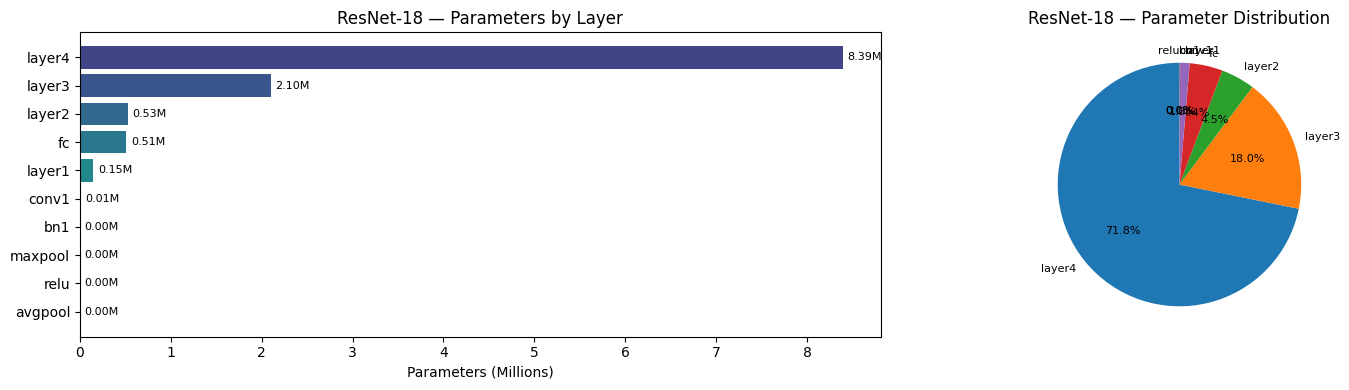

In [5]:
# --- ResNet-18 ---
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

df_r18 = layer_breakdown(resnet18, 'ResNet-18')
display(df_r18)
plot_layer_params(df_r18, 'ResNet-18')

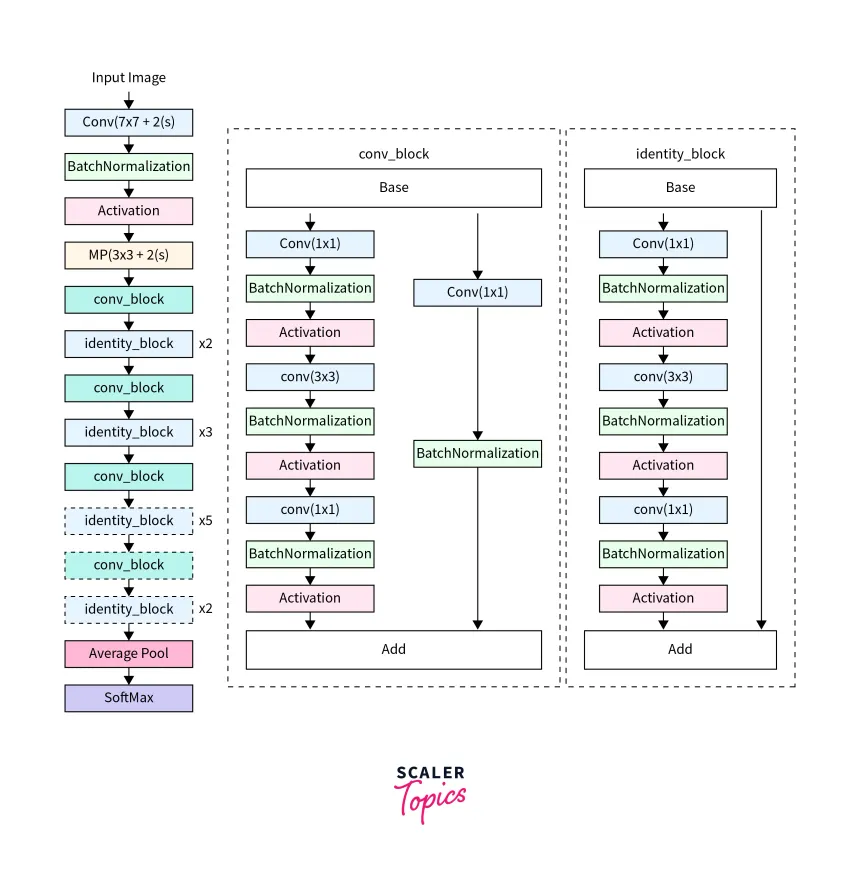 
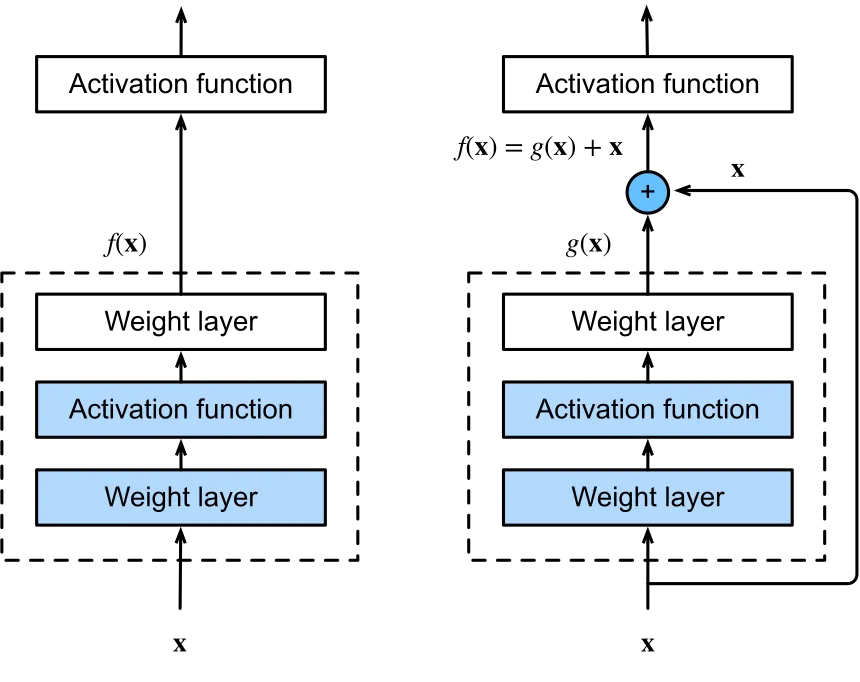

In [6]:
# --- ResNet-18: Detailed Architecture ---
print("ResNet-18 — Full Architecture")
print("Input: (B, 3, 224, 224)")
summary(resnet18, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'kernel_size'], depth=3)

ResNet-18 — Full Architecture
Input: (B, 3, 224, 224)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNet                                   [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     [7, 7]
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       --
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        3
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --                        --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           --                        --
│    │    └


  ResNet-50
  Total Parameters: 25,557,032


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,conv1,Conv2d,0,9408,9408,0.04
1,bn1,BatchNorm2d,0,128,128,0.00
2,relu,ReLU,0,0,0,0.00
3,maxpool,MaxPool2d,0,0,0,0.00
4,layer1,Sequential,27,215808,215808,0.84
5,layer2,Sequential,35,1219584,1219584,4.77
6,layer3,Sequential,51,7098368,7098368,27.77
7,layer4,Sequential,27,14964736,14964736,58.55
8,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
9,fc,Linear,0,2049000,2049000,8.02


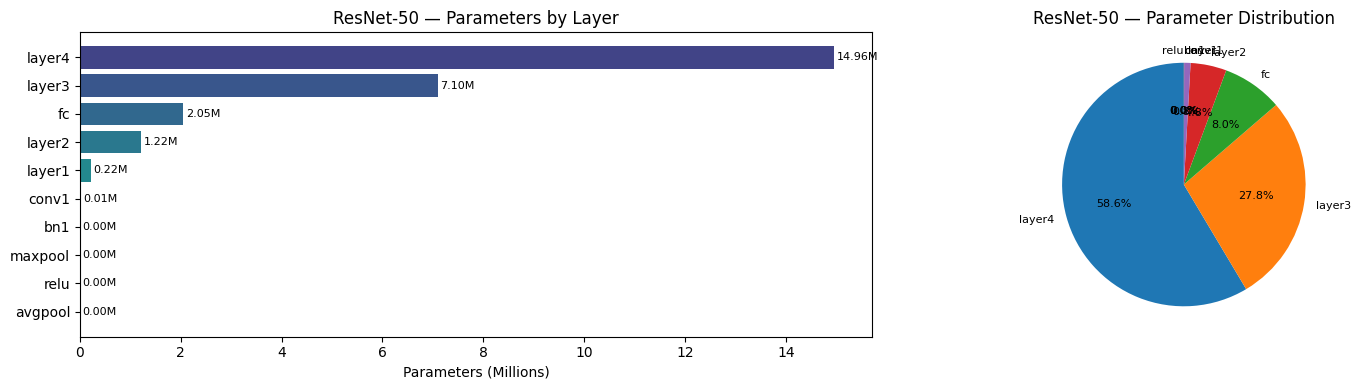

In [7]:
# --- ResNet-50 ---
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

df_r50 = layer_breakdown(resnet50, 'ResNet-50')
display(df_r50)
plot_layer_params(df_r50, 'ResNet-50')

In [8]:
# --- ResNet-50: Detailed Architecture ---
print("ResNet-50 — Full Architecture")
print("Input: (B, 3, 224, 224)")
summary(resnet50, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'kernel_size'], depth=3)

ResNet-50 — Full Architecture
Input: (B, 3, 224, 224)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNet                                   [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     [7, 7]
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       --
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        3
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 256, 56, 56]          --                        --
│    └─Bottleneck: 2-1                   [1, 64, 56, 56]           [1, 256, 56, 56]          --                        --
│    │    └

In [9]:
# --- ResNet-50: Bottleneck Block detail ---
print("ResNet-50 — Bottleneck Block Structure (layer1[0]):")
print(resnet50.layer1[0])
print("\nBottleneck: 1×1 (reduce) → 3×3 (process) → 1×1 (expand) + skip connection")
print(f"\nlayer1[0] params: {sum(p.numel() for p in resnet50.layer1[0].parameters()):,}")

ResNet-50 — Bottleneck Block Structure (layer1[0]):
Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (downsample): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

Bottleneck: 1×1 (reduce) → 3×3 (process) → 1×1 (expand) + skip connection

layer1[0] params: 75,008


## BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

Normalization လုပ်တဲ့ formula ထဲမှာ standard deviation နဲ့ စားတဲ့အခါ standard deviation က ၀ (Zero) မဖြစ်အောင် Formula ထဲက denominator မှာ ဒီ eps တန်ဖိုးလေးကို ပေါင်းထည့်ပေးထားတာပါ။


momentum = 0.1 Running Mean နဲ့ Running Variance တွေကို Update လုပ်တဲ့အခါ သုံးတဲ့ နှုန်းထား (Rate) 0.1 ဆိုတာက Batch အသစ်ကရတဲ့ တန်ဖိုးကို 10% ယူပြီး၊ အရင်က ရှိနေပြီးသား Running Statistics ကို 90% ဆက်ထိန်းထားမယ်လို့ ဆိုလိုတာပါ။ momentum = 0.1 ရဲ့ အလုပ်က ဒီလိုပါ -လက်ရှိ Batch ကရတဲ့ Mean (အသစ်) = $10\%$အရင် Batch ပေါင်းများစွာက မှတ်ထားတဲ့ Mean (အဟောင်း) = $90\%$ဒီနှစ်ခုကို ပေါင်းပြီး Running Mean အသစ် အဖြစ် Update လုပ်လိုက်တာပါ။

Model ကို Learnable Parameters နှစ်ခု ( $\gamma$ - Gamma နဲ့ $\beta$ - Beta) ပေးမပေး ဆုံးဖြတ် model က data တွေကို normal ဖြစ်အောင် လုပ်ရုံတင်မကဘဲ၊ လိုအပ်ရင် အဲဒီ data တွေကို scale ပြန်လုပ်တာ (Scaling) နဲ့ ရွှေ့တာ (Shifting) တွေကို သူ့ဘာသာသူ သင်ယူသွားမှာ ဖြစ်ပါတယ်။

store mean and variance value by training, used in inferences


  ResNet-152
  Total Parameters: 60,192,808


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,conv1,Conv2d,0,9408,9408,0.02
1,bn1,BatchNorm2d,0,128,128,0.00
2,relu,ReLU,0,0,0,0.00
3,maxpool,MaxPool2d,0,0,0,0.00
4,layer1,Sequential,27,215808,215808,0.36
5,layer2,Sequential,67,2339840,2339840,3.89
6,layer3,Sequential,291,40613888,40613888,67.47
7,layer4,Sequential,27,14964736,14964736,24.86
8,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
9,fc,Linear,0,2049000,2049000,3.40


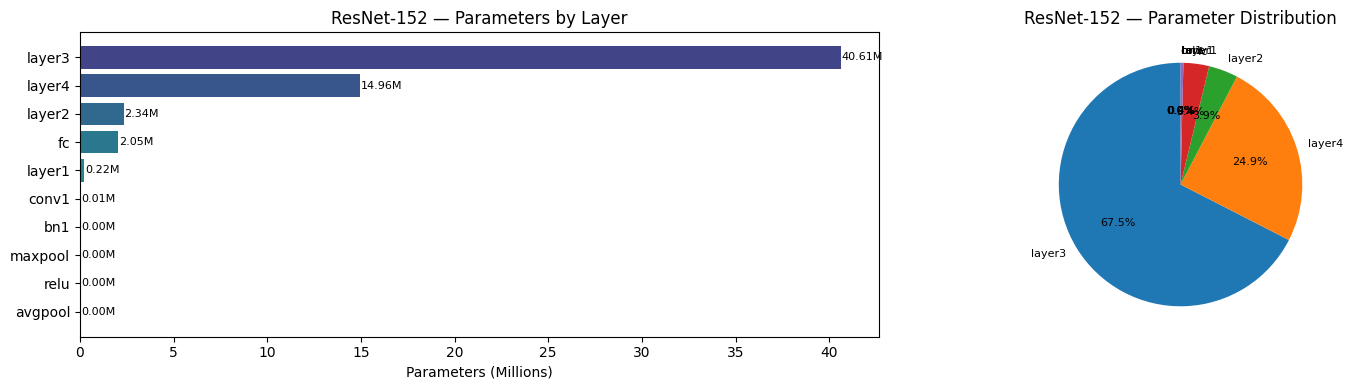

In [10]:
# --- ResNet-152 ---
resnet152 = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

df_r152 = layer_breakdown(resnet152, 'ResNet-152')
display(df_r152)
plot_layer_params(df_r152, 'ResNet-152')

In [11]:
# --- ResNet Family Comparison ---
for name, model in [('ResNet-18', resnet18), ('ResNet-50', resnet50), ('ResNet-152', resnet152)]:
    total, trainable = count_parameters(model)
    depth = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
    comparison_data.append({'Model': name, 'Total Params': total, 'Conv+FC Layers': depth})

df_resnet_cmp = pd.DataFrame(comparison_data)
df_resnet_cmp['Params (M)'] = (df_resnet_cmp['Total Params'] / 1e6).round(2)
print("ResNet Family Comparison:")
display(df_resnet_cmp[['Model', 'Params (M)', 'Conv+FC Layers']])

# Cleanup
del resnet18, resnet50, resnet152

ResNet Family Comparison:


,Model,Params (M),Conv+FC Layers
0,ResNet-18,11.69,21
1,ResNet-50,25.56,54
2,ResNet-152,60.19,156


---
## 2. EfficientNet Family

**Core Idea:** Compound Scaling — width, depth, resolution ကို balanced ဖြစ်အောင် scaling လုပ်တယ်

$$\text{depth: } d = \alpha^\phi, \quad \text{width: } w = \beta^\phi, \quad \text{resolution: } r = \gamma^\phi$$
$$\text{s.t. } \alpha \cdot \beta^2 \cdot \gamma^2 \approx 2, \quad \alpha \geq 1, \beta \geq 1, \gamma \geq 1$$

**MBConv Block** = Depthwise Separable Conv + Squeeze-and-Excitation + Skip Connection

- **B0:** Baseline (φ=0, 224×224) — 5.3M params
- **B7:** Largest (φ=6, 600×600) — 66M params


  EfficientNet-B0
  Total Parameters: 5,288,548


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,331,4007548,4007548,75.78
1,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
2,classifier,Sequential,2,1281000,1281000,24.22


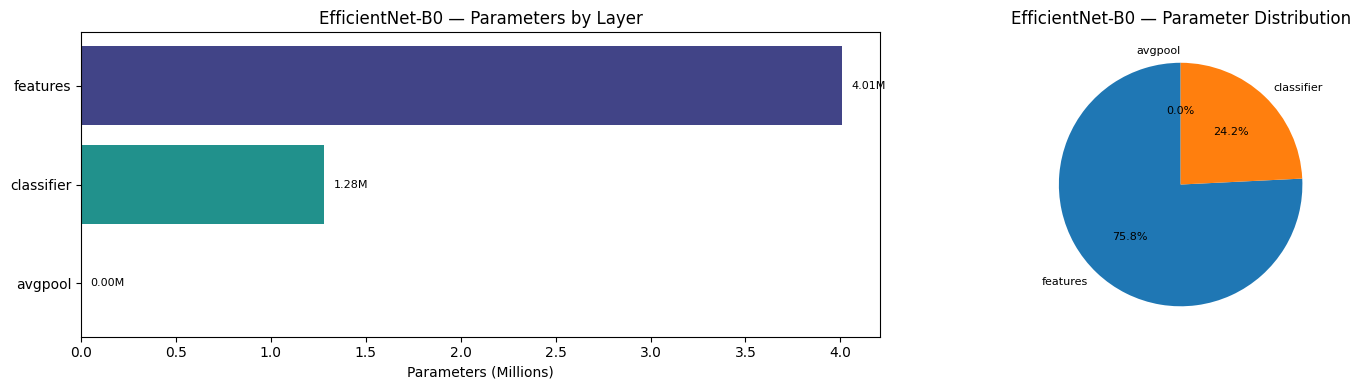

In [12]:
# --- EfficientNet-B0 ---
effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

df_eff_b0 = layer_breakdown(effnet_b0, 'EfficientNet-B0')
display(df_eff_b0)
plot_layer_params(df_eff_b0, 'EfficientNet-B0')

### Compound Scaling 
ပုံမှန်အားဖြင့် Model တစ်ခုကို ပိုကောင်းအောင်လုပ်ရင် နည်းလမ်း ၃ ခုထဲက တစ်ခုခုကိုပဲ တိုးမြှင့်လေ့ရှိပါတယ် -

Depth: Layer အရေအတွက်ကို ပိုများအောင်လုပ်တာ (ဥပမာ - ResNet-50 ကနေ ResNet-101)။

Width: Layer တစ်ခုချင်းစီမှာရှိတဲ့ Channel (Filter) အရေအတွက်ကို တိုးတာ။

Resolution: Input ပေးတဲ့ ပုံရဲ့ အရွယ်အစား (Pixel) ကို ပိုကြီးအောင်လုပ်တာ။

In [13]:
# --- EfficientNet-B0: MBConv Block detail ---
print("EfficientNet-B0 — MBConv Block Structure:")
print("features[1] (first MBConv block):")
print(effnet_b0.features[1])
print("\nMBConv: expand(1×1) → depthwise(3×3/5×5) → SE(squeeze-excitation) → project(1×1) + skip")

EfficientNet-B0 — MBConv Block Structure:
features[1] (first MBConv block):
Sequential(
  (0): MBConv(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
        (activation): SiLU(inplace=True)
        (scale_activation): Sigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (stochastic_depth): StochasticDepth(p=0.0, mode=row)
  )
)

MBConv: expand(1×1) → depthw

In [14]:
# --- EfficientNet-B0: Feature stages breakdown ---
print("EfficientNet-B0 — Feature Stages:")
print(f"{'Stage':<10} {'Type':<30} {'Output Channels':<18} {'Params':>12}")
print("-" * 75)
for i, block in enumerate(effnet_b0.features):
    params = sum(p.numel() for p in block.parameters())
    # Get output channels from the block
    out_ch = '-'
    for m in block.modules():
        if isinstance(m, nn.BatchNorm2d):
            out_ch = m.num_features
    print(f"stage[{i}]   {block.__class__.__name__:<30} {str(out_ch):<18} {params:>12,}")

total, _ = count_parameters(effnet_b0)
print(f"\nTotal: {total:,}")

EfficientNet-B0 — Feature Stages:
Stage      Type                           Output Channels          Params
---------------------------------------------------------------------------
stage[0]   Conv2dNormActivation           32                          928
stage[1]   Sequential                     16                        1,448
stage[2]   Sequential                     24                       16,714
stage[3]   Sequential                     40                       46,640
stage[4]   Sequential                     80                      242,930
stage[5]   Sequential                     112                     543,148
stage[6]   Sequential                     192                   2,026,348
stage[7]   Sequential                     320                     717,232
stage[8]   Conv2dNormActivation           1280                    412,160

Total: 5,288,548


In [15]:
# --- EfficientNet-B0: Detailed Architecture ---
print("EfficientNet-B0 — Full Architecture")
print("Input: (B, 3, 224, 224)")
summary(
    effnet_b0,
    input_size=(1, 3, 224, 224),
    col_names=['input_size', 'output_size', 'num_params', 'kernel_size'],
    depth=3
)

EfficientNet-B0 — Full Architecture
Input: (B, 3, 224, 224)


Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Kernel Shape
EfficientNet                                            [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Sequential: 1-1                                       [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        --
│    └─Conv2dNormActivation: 2-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --                        --
│    │    └─Conv2d: 3-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         864                       [3, 3]
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         [1, 32, 112, 112]         64                        --
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
│    └─Sequential: 2-2     


  EfficientNet-B7
  Total Parameters: 66,347,960


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,1099,63786960,63786960,96.14
1,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
2,classifier,Sequential,2,2561000,2561000,3.86


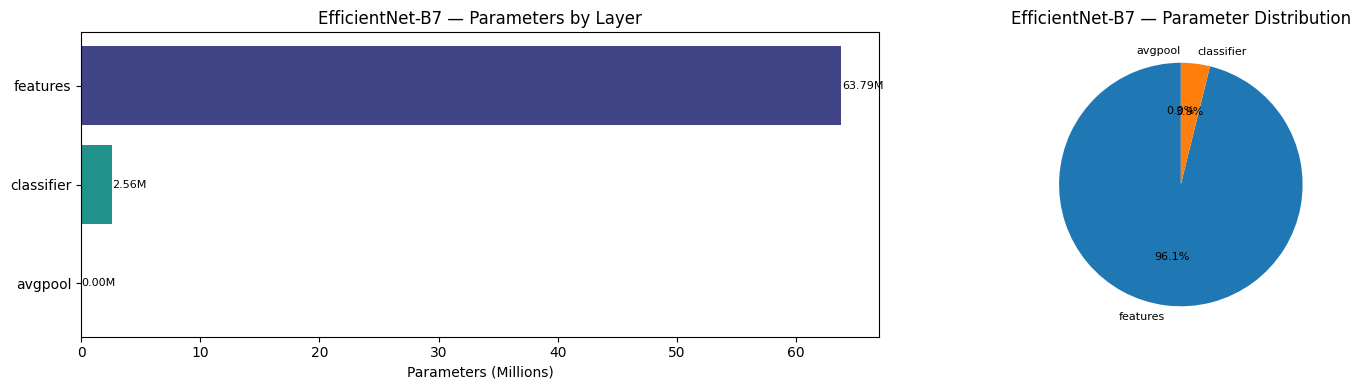

In [16]:
# --- EfficientNet-B7 ---
effnet_b7 = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT)

df_eff_b7 = layer_breakdown(effnet_b7, 'EfficientNet-B7')
display(df_eff_b7)
plot_layer_params(df_eff_b7, 'EfficientNet-B7')

In [17]:
# --- EfficientNet Comparison ---
for name, model in [('EfficientNet-B0', effnet_b0), ('EfficientNet-B7', effnet_b7)]:
    total, _ = count_parameters(model)
    depth = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
    comparison_data.append({'Model': name, 'Total Params': total, 'Conv+FC Layers': depth})

print("EfficientNet: B0 vs B7")
t0, _ = count_parameters(effnet_b0)
t7, _ = count_parameters(effnet_b7)
print(f"  B0: {t0/1e6:.1f}M params")
print(f"  B7: {t7/1e6:.1f}M params")
print(f"  Scale factor: {t7/t0:.1f}x")

del effnet_b0, effnet_b7

EfficientNet: B0 vs B7
  B0: 5.3M params
  B7: 66.3M params
  Scale factor: 12.5x


,Model,Input Size,Params (M),Top-1 Acc (%),Top-5 Acc (%),Δ Input (vs prev),Δ Top-1 (vs prev),Δ Params (M) (vs prev),Top-1 Gain vs B0,Param Scale vs B0,Input Scale vs B0
0,EfficientNet-B0,224,5.29,77.692,93.532,0,0.000,0.00,0.000,1.00,1.00
1,EfficientNet-B1,240,7.79,79.838,94.934,16,2.146,2.50,2.146,1.47,1.07
2,EfficientNet-B2,288,9.11,80.608,95.310,48,0.770,1.32,2.916,1.72,1.29
3,EfficientNet-B3,300,12.23,82.008,96.054,12,1.400,3.12,4.316,2.31,1.34
4,EfficientNet-B4,380,19.34,83.384,96.594,80,1.376,7.11,5.692,3.66,1.70
5,EfficientNet-B5,456,30.39,83.444,96.628,76,0.060,11.05,5.752,5.75,2.04
6,EfficientNet-B6,528,43.04,84.008,96.916,72,0.564,12.65,6.316,8.14,2.36
7,EfficientNet-B7,600,66.35,84.122,96.908,72,0.114,23.31,6.430,12.55,2.68


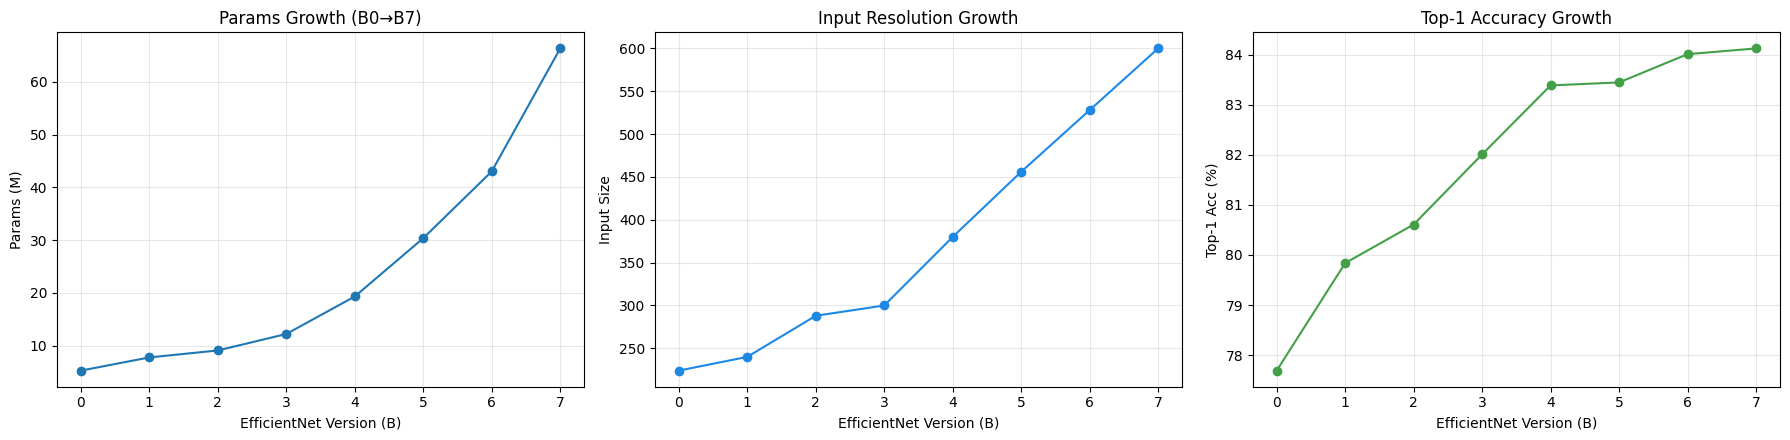

Summary (B0 -> B7):
  Input Size: 224 -> 600 (2.68x)
  Params: 5.29M -> 66.35M (12.55x)
  Top-1 Acc: 77.692% -> 84.122% (+6.430%)


In [18]:
# --- EfficientNet B0 -> B7 changes (DEFAULT weights) ---
eff_models = [f"EfficientNet-B{i}" for i in range(8)]

eff_rows = []
for model_name in eff_models:
    w = weight_classes[model_name].DEFAULT
    meta = w.meta
    metrics = meta.get("_metrics", {}).get("ImageNet-1K", {})
    crop = w.transforms().crop_size[0] if hasattr(w.transforms(), "crop_size") else None
    
    eff_rows.append({
        "Model": model_name,
        "B": int(model_name.split("-B")[-1]),
        "Input Size": crop,
        "Top-1 Acc (%)": metrics.get("acc@1", np.nan),
        "Top-5 Acc (%)": metrics.get("acc@5", np.nan),
        "Params": meta.get("num_params", np.nan)
    })

df_eff_changes = pd.DataFrame(eff_rows).sort_values("B").reset_index(drop=True)
df_eff_changes["Params (M)"] = (df_eff_changes["Params"] / 1e6).round(2)

# step-by-step changes
df_eff_changes["Δ Input (vs prev)"] = df_eff_changes["Input Size"].diff().fillna(0).astype(int)
df_eff_changes["Δ Top-1 (vs prev)"] = df_eff_changes["Top-1 Acc (%)"].diff().fillna(0).round(3)
df_eff_changes["Δ Params (M) (vs prev)"] = df_eff_changes["Params (M)"].diff().fillna(0).round(2)

# total changes vs B0
base = df_eff_changes.iloc[0]
df_eff_changes["Top-1 Gain vs B0"] = (df_eff_changes["Top-1 Acc (%)"] - base["Top-1 Acc (%)"]).round(3)
df_eff_changes["Param Scale vs B0"] = (df_eff_changes["Params"] / base["Params"]).round(2)
df_eff_changes["Input Scale vs B0"] = (df_eff_changes["Input Size"] / base["Input Size"]).round(2)

display(df_eff_changes[
    ["Model", "Input Size", "Params (M)", "Top-1 Acc (%)", "Top-5 Acc (%)",
     "Δ Input (vs prev)", "Δ Top-1 (vs prev)", "Δ Params (M) (vs prev)",
     "Top-1 Gain vs B0", "Param Scale vs B0", "Input Scale vs B0"]
])

# quick visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(df_eff_changes["B"], df_eff_changes["Params (M)"], marker="o")
axes[0].set_title("Params Growth (B0→B7)")
axes[0].set_xlabel("EfficientNet Version (B)")
axes[0].set_ylabel("Params (M)")
axes[0].grid(alpha=0.3)

axes[1].plot(df_eff_changes["B"], df_eff_changes["Input Size"], marker="o", color="#1E88E5")
axes[1].set_title("Input Resolution Growth")
axes[1].set_xlabel("EfficientNet Version (B)")
axes[1].set_ylabel("Input Size")
axes[1].grid(alpha=0.3)

axes[2].plot(df_eff_changes["B"], df_eff_changes["Top-1 Acc (%)"], marker="o", color="#43A047")
axes[2].set_title("Top-1 Accuracy Growth")
axes[2].set_xlabel("EfficientNet Version (B)")
axes[2].set_ylabel("Top-1 Acc (%)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Summary (B0 -> B7):")
print(f"  Input Size: {int(base['Input Size'])} -> {int(df_eff_changes.iloc[-1]['Input Size'])} "
      f"({df_eff_changes.iloc[-1]['Input Scale vs B0']:.2f}x)")
print(f"  Params: {base['Params']/1e6:.2f}M -> {df_eff_changes.iloc[-1]['Params']/1e6:.2f}M "
      f"({df_eff_changes.iloc[-1]['Param Scale vs B0']:.2f}x)")
print(f"  Top-1 Acc: {base['Top-1 Acc (%)']:.3f}% -> {df_eff_changes.iloc[-1]['Top-1 Acc (%)']:.3f}% "
      f"(+{df_eff_changes.iloc[-1]['Top-1 Gain vs B0']:.3f}%)")

###  MBConv (Mobile Inverted Bottleneck) - Mobile Net Family မှာသုံးထားတဲ့ကောင်ကို Efficient Net မှာလည်းသုံးထားတယ်။
##### Depthwise Separable Convolution Slide CM4M2 Slide ကိုကြည့်ပါ။


---
## 3. MobileNet Family

**Core Idea:** Depthwise Separable Convolution — standard conv ကို depthwise + pointwise ခွဲပြီး computation ကိုလျှော့ချတယ်

**Standard Conv cost:**
$$D_K^2 \cdot M \cdot N \cdot D_F^2$$

**Depthwise Separable Conv cost:**
$$D_K^2 \cdot M \cdot D_F^2 + M \cdot N \cdot D_F^2$$

**Cost reduction ratio:**
$$\frac{1}{N} + \frac{1}{D_K^2} \quad \text{(~8-9× cheaper for 3×3 kernels)}$$

- $D_K$ = kernel size, $M$ = input channels, $N$ = output channels, $D_F$ = feature map size

**MobileNetV2** adds Inverted Residuals: thin→wide→thin (opposite of ResNet bottleneck)

**MobileNetV3** adds SE blocks + h-swish activation + NAS-searched architecture


  MobileNetV2
  Total Parameters: 3,504,872


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,208,2223872,2223872,63.45
1,classifier,Sequential,2,1281000,1281000,36.55


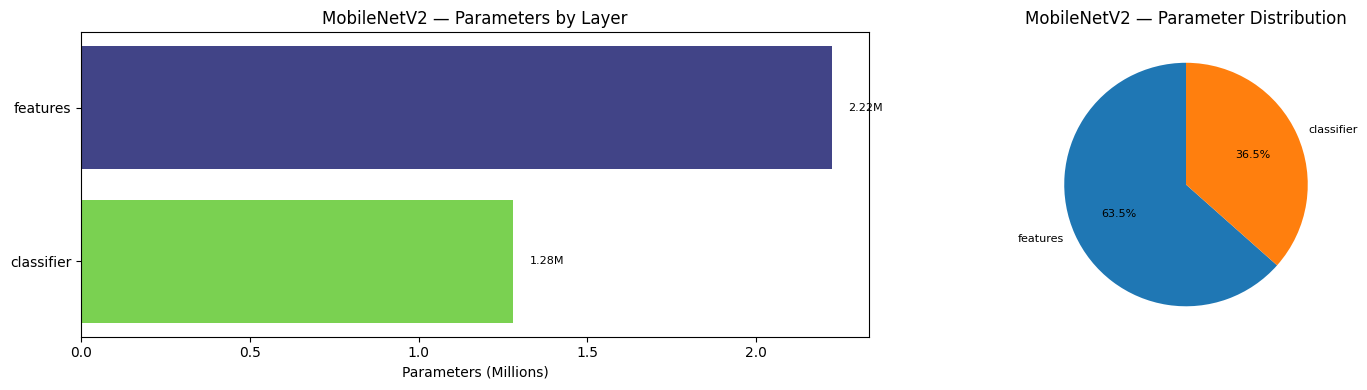

In [19]:
# --- MobileNetV2 ---
mobilenet_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

df_mv2 = layer_breakdown(mobilenet_v2, 'MobileNetV2')
display(df_mv2)
plot_layer_params(df_mv2, 'MobileNetV2')    

In [20]:
# --- MobileNetV2: Inverted Residual Block detail ---
print("MobileNetV2 — Inverted Residual Block:")
print("features[1] (first InvertedResidual):")
print(mobilenet_v2.features[1])
print("\nInverted Residual: expand(1×1, pointwise) → depthwise(3×3) → project(1×1, pointwise)")
print("  Unlike ResNet bottleneck: wide→narrow→wide")
print("  MobileNet inverted:      narrow→wide→narrow")

# Show depthwise conv breakdown
block = mobilenet_v2.features[2]
print(f"\nfeatures[2] block params breakdown:")
for name, m in block.named_modules():
    if isinstance(m, (nn.Conv2d, nn.BatchNorm2d, nn.Linear)):
        p = sum(p.numel() for p in m.parameters())
        extra = f" [groups={m.groups}]" if isinstance(m, nn.Conv2d) and m.groups > 1 else ""
        print(f"  {name:<25} {m.__class__.__name__:<15} params: {p:>8,}{extra}")

MobileNetV2 — Inverted Residual Block:
features[1] (first InvertedResidual):
InvertedResidual(
  (conv): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

Inverted Residual: expand(1×1, pointwise) → depthwise(3×3) → project(1×1, pointwise)
  Unlike ResNet bottleneck: wide→narrow→wide
  MobileNet inverted:      narrow→wide→narrow

features[2] block params breakdown:
  conv.0.0                  Conv2d          params:    1,536
  conv.0.1                  BatchNorm2d     params:      192
  conv.1.0                  Conv2d          params:      864 [groups=96]
  conv.1.1                  BatchNorm2d     param


  MobileNetV3-Large
  Total Parameters: 5,483,032


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,247,2971952,2971952,54.2
1,avgpool,AdaptiveAvgPool2d,0,0,0,0.0
2,classifier,Sequential,4,2511080,2511080,45.8


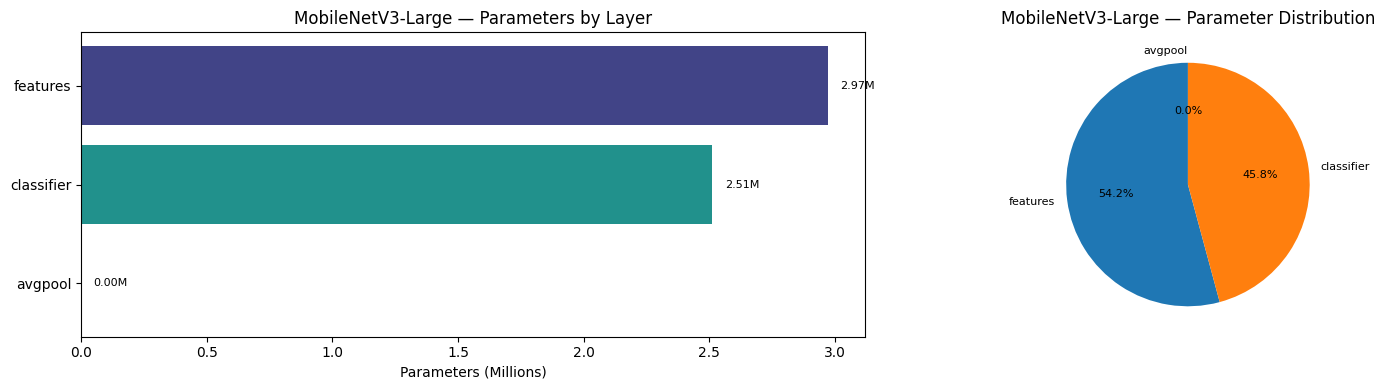

In [21]:
# --- MobileNetV3-Large ---
mobilenet_v3 = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

df_mv3 = layer_breakdown(mobilenet_v3, 'MobileNetV3-Large')
display(df_mv3)
plot_layer_params(df_mv3, 'MobileNetV3-Large')

In [22]:
# --- MobileNetV3: SE block + h-swish ---
print("MobileNetV3-Large — Block with Squeeze-Excitation:")
# Find a block with SE
for i, block in enumerate(mobilenet_v3.features):
    has_se = any(isinstance(m, nn.AdaptiveAvgPool2d) for m in block.modules())
    if has_se and i > 0:
        print(f"features[{i}]:")
        print(block)
        print(f"\nParams: {sum(p.numel() for p in block.parameters()):,}")
        break

print("\nNew in V3: h-swish activation, SE modules, NAS-optimized")

MobileNetV3-Large — Block with Squeeze-Excitation:
features[4]:
InvertedResidual(
  (block): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(24, 72, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(72, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(72, 72, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), groups=72, bias=False)
      (1): BatchNorm2d(72, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): SqueezeExcitation(
      (avgpool): AdaptiveAvgPool2d(output_size=1)
      (fc1): Conv2d(72, 24, kernel_size=(1, 1), stride=(1, 1))
      (fc2): Conv2d(24, 72, kernel_size=(1, 1), stride=(1, 1))
      (activation): ReLU()
      (scale_activation): Hardsigmoid()
    )
    (3): Conv2dNormActivation(
      (0): Conv2d(72, 40, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(

In [23]:
# --- MobileNet V2 vs V3 ---
for name, model in [('MobileNetV2', mobilenet_v2), ('MobileNetV3-Large', mobilenet_v3)]:
    total, _ = count_parameters(model)
    depth = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
    comparison_data.append({'Model': name, 'Total Params': total, 'Conv+FC Layers': depth})

t2, _ = count_parameters(mobilenet_v2)
t3, _ = count_parameters(mobilenet_v3)
print(f"MobileNetV2:      {t2/1e6:.1f}M params")
print(f"MobileNetV3-Large: {t3/1e6:.1f}M params")

del mobilenet_v2, mobilenet_v3

MobileNetV2:      3.5M params
MobileNetV3-Large: 5.5M params


---
## 4. ConvNeXt Family

**Core Idea:** Pure ConvNet ကို Vision Transformer (ViT) ရဲ့ design choices တွေနဲ့ modernize လုပ်ထားတယ်

**Key design changes from ResNet:**
1. Patchify stem (4×4, stride 4) — like ViT
2. Inverted bottleneck (wide→narrow, like MobileNet)
3. Large kernel (7×7 depthwise conv)
4. LayerNorm instead of BatchNorm
5. GELU activation instead of ReLU
6. Fewer activation & norm layers


  ConvNeXt-Tiny
  Total Parameters: 28,589,128


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,196,27818592,27818592,97.3
1,avgpool,AdaptiveAvgPool2d,0,0,0,0.0
2,classifier,Sequential,3,770536,770536,2.7


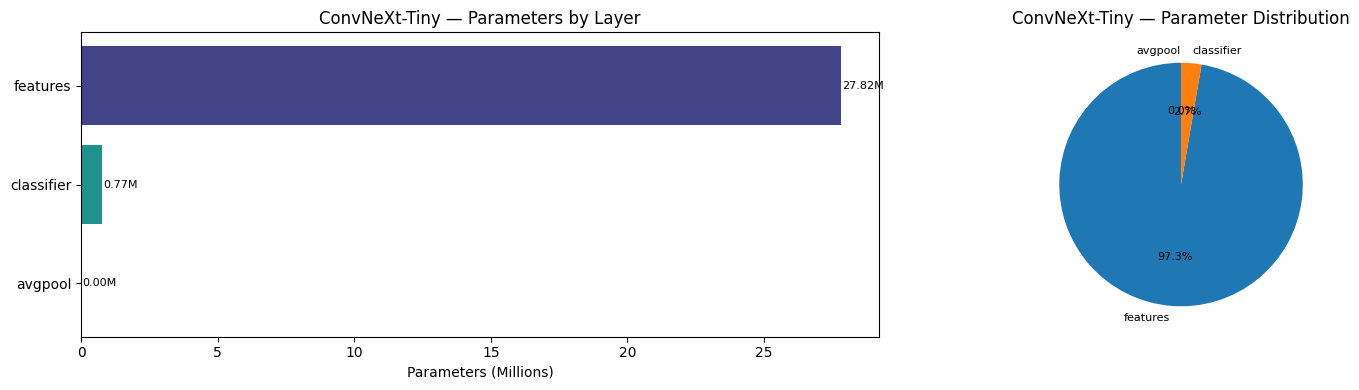

In [24]:
# --- ConvNeXt-Tiny ---
convnext_tiny = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

df_cnxt = layer_breakdown(convnext_tiny, 'ConvNeXt-Tiny')
display(df_cnxt)
plot_layer_params(df_cnxt, 'ConvNeXt-Tiny')

In [25]:
# --- ConvNeXt-Tiny: Block detail ---
print("ConvNeXt-Tiny — Block Structure:")
print("features[1] (first ConvNeXt stage):")
# Show first block of first stage
first_stage = convnext_tiny.features[1]
print(first_stage[0] if hasattr(first_stage, '__getitem__') else first_stage)

print("\nKey differences from ResNet:")
print("  • 7×7 depthwise conv (large receptive field)")
print("  • LayerNorm (not BatchNorm)")
print("  • GELU activation (not ReLU)")
print("  • Inverted bottleneck: channels expand 4× then shrink")

ConvNeXt-Tiny — Block Structure:
features[1] (first ConvNeXt stage):
CNBlock(
  (block): Sequential(
    (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
    (1): Permute()
    (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=96, out_features=384, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=384, out_features=96, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.0, mode=row)
)

Key differences from ResNet:
  • 7×7 depthwise conv (large receptive field)
  • LayerNorm (not BatchNorm)
  • GELU activation (not ReLU)
  • Inverted bottleneck: channels expand 4× then shrink


In [26]:
# --- ConvNeXt-Tiny: Detailed Architecture ---
print("ConvNeXt-Tiny — Detailed Architecture")
summary(convnext_tiny, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'kernel_size'], depth=3)

ConvNeXt-Tiny — Detailed Architecture


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
ConvNeXt                                      [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Sequential: 1-1                             [1, 3, 224, 224]          [1, 768, 7, 7]            --                        --
│    └─Conv2dNormActivation: 2-1              [1, 3, 224, 224]          [1, 96, 56, 56]           --                        --
│    │    └─Conv2d: 3-1                       [1, 3, 224, 224]          [1, 96, 56, 56]           4,704                     [4, 4]
│    │    └─LayerNorm2d: 3-2                  [1, 96, 56, 56]           [1, 96, 56, 56]           192                       --
│    └─Sequential: 2-2                        [1, 96, 56, 56]           [1, 96, 56, 56]           --                        --
│    │    └─CNBlock: 3-3                      [1, 96, 56, 56]           [1, 96, 56, 56]          


  ConvNeXt-Base
  Total Parameters: 88,591,464


,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,features,Sequential,376,87564416,87564416,98.84
1,avgpool,AdaptiveAvgPool2d,0,0,0,0.00
2,classifier,Sequential,3,1027048,1027048,1.16


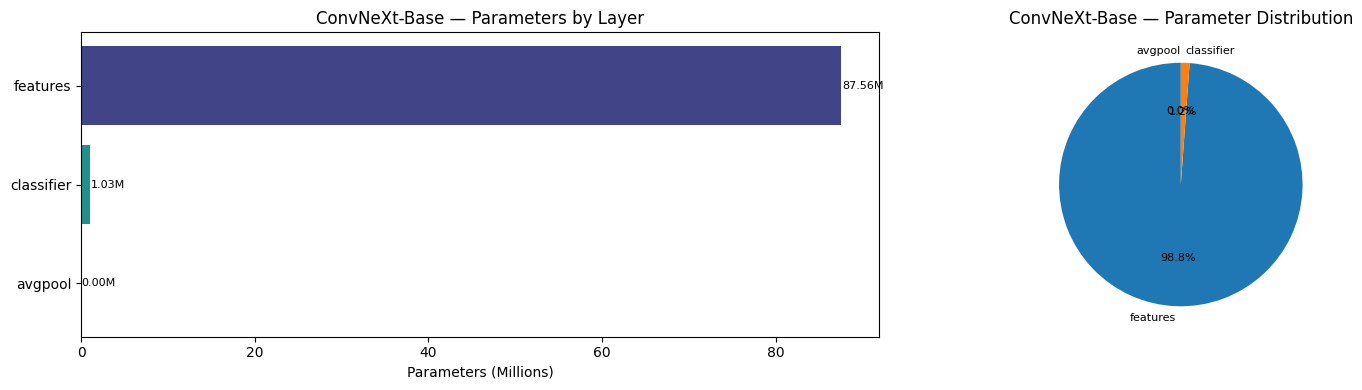

In [27]:
# --- ConvNeXt-Base ---
convnext_base = models.convnext_base(weights=models.ConvNeXt_Base_Weights.DEFAULT)

df_cnxb = layer_breakdown(convnext_base, 'ConvNeXt-Base')
display(df_cnxb)
plot_layer_params(df_cnxb, 'ConvNeXt-Base')

In [28]:
# --- ConvNeXt Comparison ---
for name, model in [('ConvNeXt-Tiny', convnext_tiny), ('ConvNeXt-Base', convnext_base)]:
    total, _ = count_parameters(model)
    depth = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
    comparison_data.append({'Model': name, 'Total Params': total, 'Conv+FC Layers': depth})

tt, _ = count_parameters(convnext_tiny)
tb, _ = count_parameters(convnext_base)
print(f"ConvNeXt-Tiny: {tt/1e6:.1f}M params")
print(f"ConvNeXt-Base: {tb/1e6:.1f}M params")

del convnext_tiny, convnext_base

ConvNeXt-Tiny: 28.6M params
ConvNeXt-Base: 88.6M params


---
## 5. InceptionResNetV2 (FaceNet Backbone)

**Core Idea:** Inception modules (parallel multi-scale convolutions) + Residual connections

**Inception module:** input ကို 1×1, 3×3, 5×5 convolutions parallel run ပြီး concatenate လုပ်တယ်

**FaceNet** သည် face recognition အတွက် InceptionResNetV1/V2 ကို backbone အဖြစ်သုံးပြီး
triplet loss နဲ့ face embeddings (128/512-dim) ကို learn လုပ်တယ်

$$L = \sum_i \left[ \|f(x_i^a) - f(x_i^p)\|_2^2 - \|f(x_i^a) - f(x_i^n)\|_2^2 + \alpha \right]_+$$

> `facenet-pytorch` package ကို install လုပ်ပြီးသုံးပါမယ်

In [29]:
# --- Install facenet-pytorch (if needed) ---
try:
    from facenet_pytorch import InceptionResnetV1
    print("facenet-pytorch already installed")
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'facenet-pytorch', '-q'])
    from facenet_pytorch import InceptionResnetV1
    print("facenet-pytorch installed successfully")

facenet-pytorch already installed


c:\Users\RAIDER\anaconda3\envs\vision.ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  InceptionResNetV1 (FaceNet)
  Total Parameters: 27,910,327


c:\Users\RAIDER\anaconda3\envs\vision.ai\lib\site-packages\facenet_pytorch\models\inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torc

,Layer,Type,Sub-layers,Parameters,Trainable,% of Total
0,conv2d_1a,BasicConv2d,3,928,928,0.00
1,conv2d_2a,BasicConv2d,3,9280,9280,0.03
2,conv2d_2b,BasicConv2d,3,18560,18560,0.07
3,maxpool_3a,MaxPool2d,0,0,0,0.00
4,conv2d_3b,BasicConv2d,3,5280,5280,0.02
5,conv2d_4a,BasicConv2d,3,138624,138624,0.50
6,conv2d_4b,BasicConv2d,3,442880,442880,1.59
7,repeat_1,Sequential,145,387200,387200,1.39
8,mixed_6a,Mixed_6a,18,1710080,1710080,6.13
9,repeat_2,Sequential,200,6900480,6900480,24.72


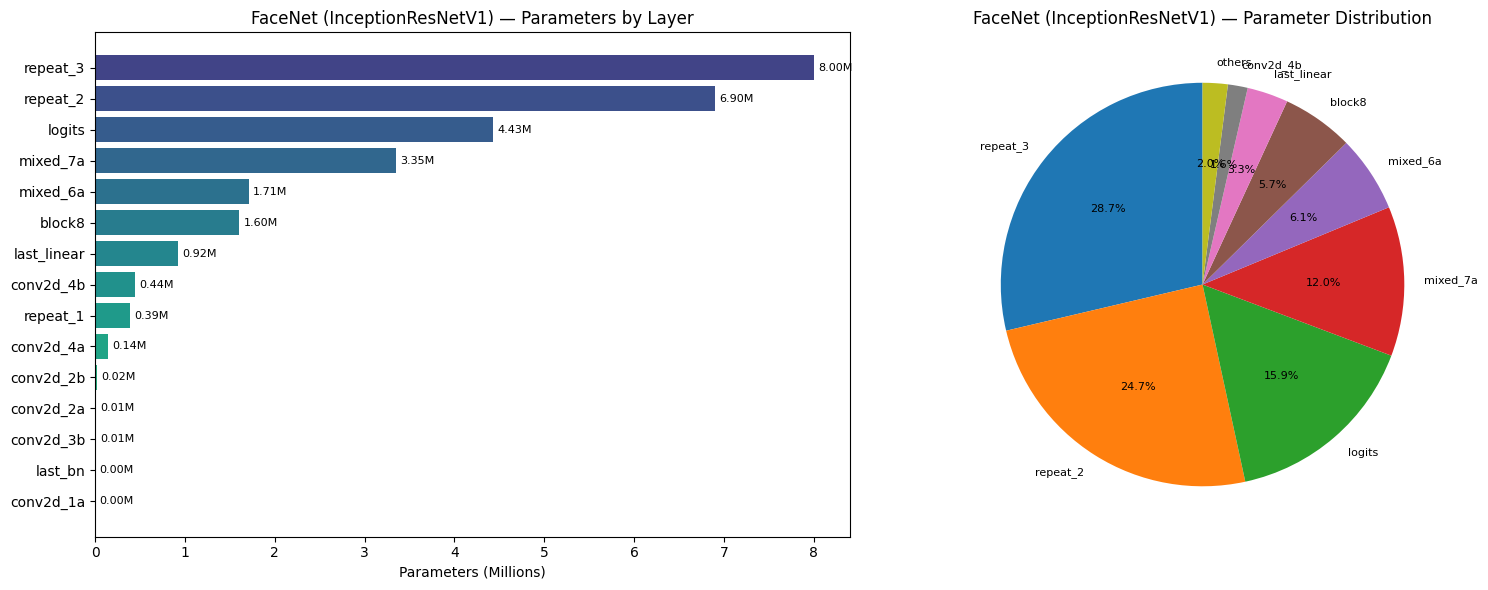

In [30]:
# --- InceptionResNetV1 (FaceNet) ---
facenet = InceptionResnetV1(pretrained='vggface2')  # pretrained on VGGFace2

df_facenet = layer_breakdown(facenet, 'InceptionResNetV1 (FaceNet)')
display(df_facenet)
plot_layer_params(df_facenet, 'FaceNet (InceptionResNetV1)')

In [31]:
# --- FaceNet: Key blocks ---
print("FaceNet — Key Architecture Components:\n")

# Show stem
print("1. Stem (conv2d_1a → conv2d_4b):")
stem_params = 0
for name, module in facenet.named_children():
    if 'conv2d' in name or 'maxpool' in name:
        p = sum(p.numel() for p in module.parameters())
        stem_params += p
        if p > 0:
            print(f"  {name:<20} params: {p:>10,}")
    if name == 'conv2d_4b':
        break

# Show inception blocks
print(f"\n2. Inception blocks:")
for name, module in facenet.named_children():
    if 'repeat' in name or 'mixed' in name or 'block' in name:
        p = sum(p.numel() for p in module.parameters())
        if p > 0:
            print(f"  {name:<20} params: {p:>10,}")

# Final embedding
print(f"\n3. Final layers:")
for name, module in facenet.named_children():
    if 'last' in name or 'logits' in name:
        p = sum(p.numel() for p in module.parameters())
        if p > 0:
            print(f"  {name:<20} params: {p:>10,}")

total, _ = count_parameters(facenet)
print(f"\nOutput: 512-dim face embedding vector")
print(f"Total: {total:,} ({total/1e6:.1f}M)")

FaceNet — Key Architecture Components:

1. Stem (conv2d_1a → conv2d_4b):
  conv2d_1a            params:        928
  conv2d_2a            params:      9,280
  conv2d_2b            params:     18,560
  conv2d_3b            params:      5,280
  conv2d_4a            params:    138,624
  conv2d_4b            params:    442,880

2. Inception blocks:
  repeat_1             params:    387,200
  mixed_6a             params:  1,710,080
  repeat_2             params:  6,900,480
  mixed_7a             params:  3,346,176
  repeat_3             params:  8,003,840
  block8               params:  1,600,768

3. Final layers:
  last_linear          params:    917,504
  last_bn              params:      1,024
  logits               params:  4,427,703

Output: 512-dim face embedding vector
Total: 27,910,327 (27.9M)


In [32]:
# --- FaceNet: torchinfo summary ---
print("FaceNet (InceptionResNetV1) — Architecture")
print("Input: (B, 3, 160, 160) — standard FaceNet input size")
summary(facenet, input_size=(1, 3, 160, 160), col_names=['input_size', 'output_size', 'num_params'], depth=2)

FaceNet (InceptionResNetV1) — Architecture
Input: (B, 3, 160, 160) — standard FaceNet input size


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
InceptionResnetV1                             [1, 3, 160, 160]          [1, 512]                  4,427,703
├─BasicConv2d: 1-1                            [1, 3, 160, 160]          [1, 32, 79, 79]           --
│    └─Conv2d: 2-1                            [1, 3, 160, 160]          [1, 32, 79, 79]           864
│    └─BatchNorm2d: 2-2                       [1, 32, 79, 79]           [1, 32, 79, 79]           64
│    └─ReLU: 2-3                              [1, 32, 79, 79]           [1, 32, 79, 79]           --
├─BasicConv2d: 1-2                            [1, 32, 79, 79]           [1, 32, 77, 77]           --
│    └─Conv2d: 2-4                            [1, 32, 79, 79]           [1, 32, 77, 77]           9,216
│    └─BatchNorm2d: 2-5                       [1, 32, 77, 77]           [1, 32, 77, 77]           64
│    └─ReLU: 2-6                              [1, 32, 77, 77]           [1,

In [33]:
# --- Add FaceNet to comparison ---
total, _ = count_parameters(facenet)
depth = sum(1 for m in facenet.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
comparison_data.append({'Model': 'FaceNet (IncResV1)', 'Total Params': total, 'Conv+FC Layers': depth})

del facenet

---
## 6. All Models Comparison

In [34]:
# --- Final Comparison: All Models ---
df_all = pd.DataFrame(comparison_data)
df_all['Params (M)'] = (df_all['Total Params'] / 1e6).round(2)
df_all = df_all.sort_values('Total Params').reset_index(drop=True)

print("="*65)
print("  All Pretrained Models — Parameter Comparison")
print("="*65)
display(df_all[['Model', 'Params (M)', 'Conv+FC Layers']])

  All Pretrained Models — Parameter Comparison


,Model,Params (M),Conv+FC Layers
0,MobileNetV2,3.50,53
1,EfficientNet-B0,5.29,82
2,MobileNetV3-Large,5.48,64
3,ResNet-18,11.69,21
4,ResNet-50,25.56,54
5,FaceNet (IncResV1),27.91,134
6,ConvNeXt-Tiny,28.59,59
7,ResNet-152,60.19,156
8,EfficientNet-B7,66.35,274
9,ConvNeXt-Base,88.59,113


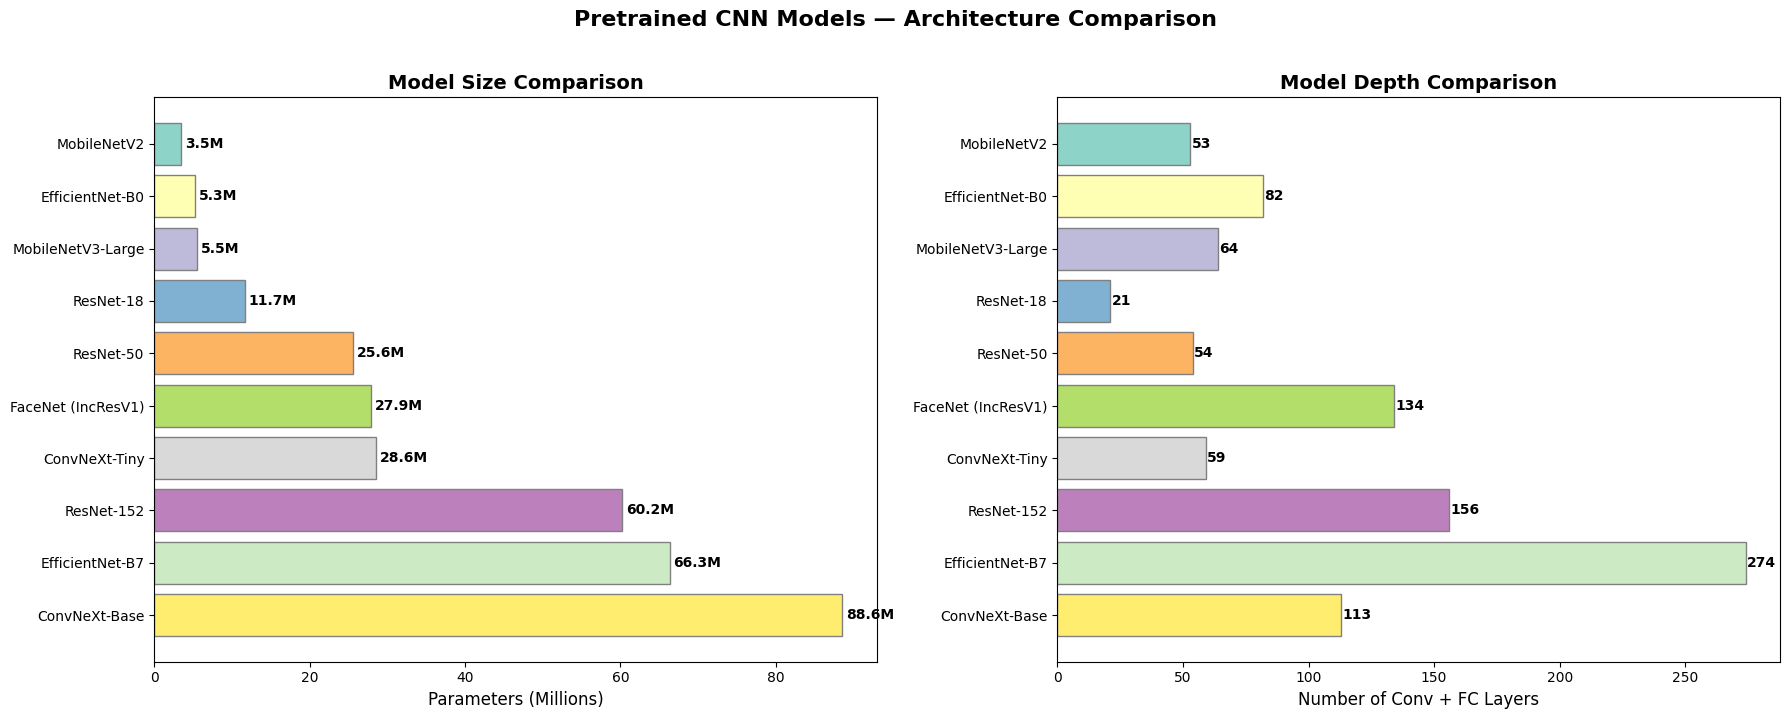

In [35]:
# --- Visualization: All Models Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (1) Parameters bar chart
colors = plt.cm.Set3(np.linspace(0, 1, len(df_all)))
bars = axes[0].barh(df_all['Model'], df_all['Params (M)'], color=colors, edgecolor='gray')
axes[0].set_xlabel('Parameters (Millions)', fontsize=12)
axes[0].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, df_all['Params (M)']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=10, fontweight='bold')

# (2) Conv+FC layers bar chart
bars2 = axes[1].barh(df_all['Model'], df_all['Conv+FC Layers'], color=colors, edgecolor='gray')
axes[1].set_xlabel('Number of Conv + FC Layers', fontsize=12)
axes[1].set_title('Model Depth Comparison', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars2, df_all['Conv+FC Layers']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')

plt.suptitle('Pretrained CNN Models — Architecture Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

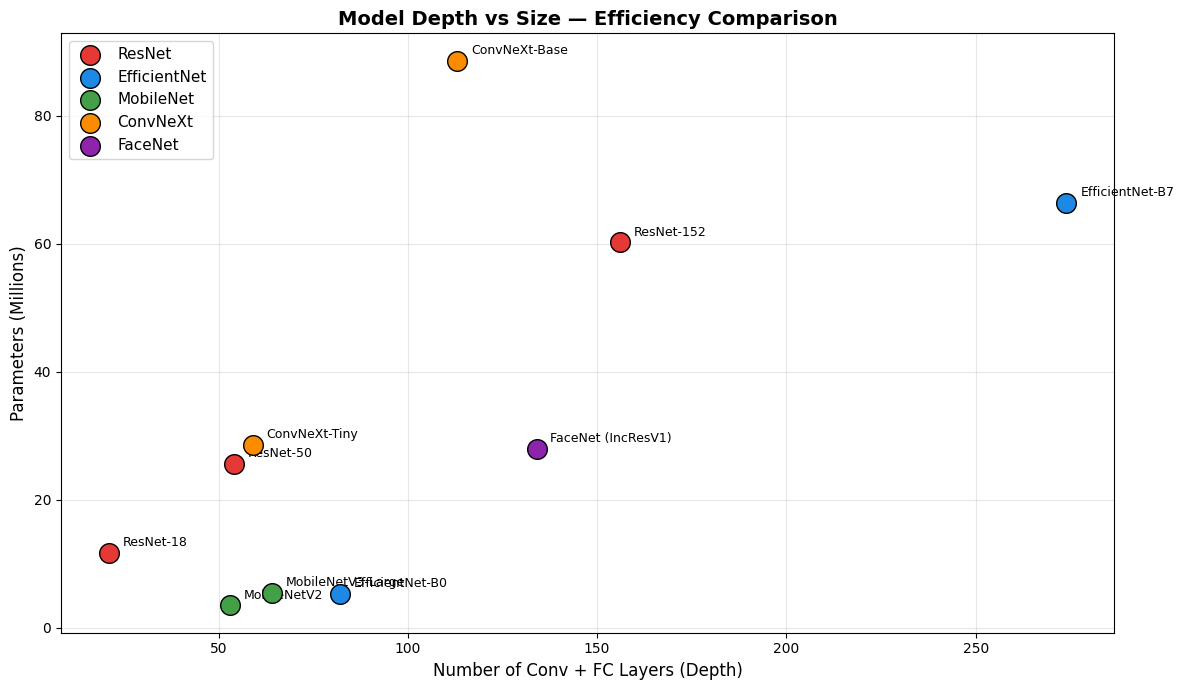


Key Insights:
  • MobileNet: smallest params — designed for mobile/edge devices
  • EfficientNet: best accuracy-per-param ratio via compound scaling
  • ResNet: simple, reliable, widely used baseline
  • ConvNeXt: modern design matching ViT performance with pure convolutions
  • FaceNet: specialized for face embedding, moderate size


In [36]:
# --- Params vs Depth scatter ---
fig, ax = plt.subplots(figsize=(12, 7))

families = {
    'ResNet': ['ResNet-18', 'ResNet-50', 'ResNet-152'],
    'EfficientNet': ['EfficientNet-B0', 'EfficientNet-B7'],
    'MobileNet': ['MobileNetV2', 'MobileNetV3-Large'],
    'ConvNeXt': ['ConvNeXt-Tiny', 'ConvNeXt-Base'],
    'FaceNet': ['FaceNet (IncResV1)']
}
family_colors = {'ResNet': '#E53935', 'EfficientNet': '#1E88E5', 'MobileNet': '#43A047',
                 'ConvNeXt': '#FB8C00', 'FaceNet': '#8E24AA'}

for family, model_names in families.items():
    subset = df_all[df_all['Model'].isin(model_names)]
    ax.scatter(subset['Conv+FC Layers'], subset['Params (M)'],
               s=200, label=family, color=family_colors[family], edgecolors='black', zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['Model'], (row['Conv+FC Layers'], row['Params (M)']),
                    textcoords='offset points', xytext=(10, 5), fontsize=9)

ax.set_xlabel('Number of Conv + FC Layers (Depth)', fontsize=12)
ax.set_ylabel('Parameters (Millions)', fontsize=12)
ax.set_title('Model Depth vs Size — Efficiency Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("  • MobileNet: smallest params — designed for mobile/edge devices")
print("  • EfficientNet: best accuracy-per-param ratio via compound scaling")
print("  • ResNet: simple, reliable, widely used baseline")
print("  • ConvNeXt: modern design matching ViT performance with pure convolutions")
print("  • FaceNet: specialized for face embedding, moderate size")